In [156]:
import pandas as pd

DATA_PATH = 'C:/Users/Reyhane/Desktop/Aiolearn/jalase31/data/US_Accidents_March23.csv'

data = pd.read_csv(DATA_PATH,chunksize=1_000_0)

df = next(data)

len(df)


10000

In [157]:
drop_columns = ['ID', 'Source','Timezone', 'Airport_Code','End_Time','Zipcode','Description','Wind_Speed(mph)']

df.drop(columns=drop_columns,inplace=True)

In [158]:
df.head()

,Severity,Start_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Street,City,County,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,3,2016-02-08 05:46:00,39.865147,-84.058723,NaN,NaN,0.01,I-70 E,Dayton,Montgomery,...,False,False,False,False,False,False,Night,Night,Night,Night
1,2,2016-02-08 06:07:59,39.928059,-82.831184,NaN,NaN,0.01,Brice Rd,Reynoldsburg,Franklin,...,False,False,False,False,False,False,Night,Night,Night,Day
2,2,2016-02-08 06:49:27,39.063148,-84.032608,NaN,NaN,0.01,State Route 32,Williamsburg,Clermont,...,False,False,False,False,True,False,Night,Night,Day,Day
3,3,2016-02-08 07:23:34,39.747753,-84.205582,NaN,NaN,0.01,I-75 S,Dayton,Montgomery,...,False,False,False,False,False,False,Night,Day,Day,Day
4,2,2016-02-08 07:39:07,39.627781,-84.188354,NaN,NaN,0.01,Miamisburg Centerville Rd,Dayton,Montgomery,...,False,False,False,False,True,False,Day,Day,Day,Day


In [159]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Severity               10000 non-null  int64  
 1   Start_Time             10000 non-null  str    
 2   Start_Lat              10000 non-null  float64
 3   Start_Lng              10000 non-null  float64
 4   End_Lat                0 non-null      float64
 5   End_Lng                0 non-null      float64
 6   Distance(mi)           10000 non-null  float64
 7   Street                 10000 non-null  str    
 8   City                   10000 non-null  str    
 9   County                 10000 non-null  str    
 10  State                  10000 non-null  str    
 11  Country                10000 non-null  str    
 12  Weather_Timestamp      9969 non-null   str    
 13  Temperature(F)         9915 non-null   float64
 14  Wind_Chill(F)          1426 non-null   float64
 15  Humidity(%)   

In [160]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Severity,10000.0,2.394700,0.491260,1.000000,2.000000,2.000000,3.000000,4.000000
Start_Lat,10000.0,38.128680,0.749559,36.352592,37.643864,37.959778,38.574538,41.428753
Start_Lng,10000.0,-119.041084,9.963780,-123.810753,-122.159031,-121.875954,-121.349976,-81.550728
End_Lat,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
End_Lng,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance(mi),10000.0,0.021386,0.397797,0.000000,0.000000,0.010000,0.010000,24.040000
Temperature(F),9915.0,59.643732,17.369289,3.900000,48.200000,57.000000,71.100000,106.000000
Wind_Chill(F),1426.0,33.126157,10.297458,-8.400000,27.500000,36.400000,40.800000,66.000000
Humidity(%),9876.0,64.083131,24.475341,8.000000,46.000000,67.000000,86.000000,100.000000
Pressure(in),9965.0,30.012505,0.316665,3.010000,29.900000,30.010000,30.120000,30.620000


In [161]:
missing_values = (
    df.
    isna()
    .sum()
)

missing = pd.DataFrame(data=missing_values,columns=['missing_value'])
missing['missing_percentage'] = missing * 100 / len(df)
missing

,missing_value,missing_percentage
Severity,0,0.00
Start_Time,0,0.00
Start_Lat,0,0.00
Start_Lng,0,0.00
End_Lat,10000,100.00
End_Lng,10000,100.00
Distance(mi),0,0.00
Street,0,0.00
City,0,0.00
County,0,0.00


In [162]:
treshold=0.5
missing_ratio=df.isnull().mean()
missing_drop=missing_ratio[
    missing_ratio>treshold
].index
df.drop(columns=missing_drop,inplace=True)


In [163]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Severity               10000 non-null  int64  
 1   Start_Time             10000 non-null  str    
 2   Start_Lat              10000 non-null  float64
 3   Start_Lng              10000 non-null  float64
 4   Distance(mi)           10000 non-null  float64
 5   Street                 10000 non-null  str    
 6   City                   10000 non-null  str    
 7   County                 10000 non-null  str    
 8   State                  10000 non-null  str    
 9   Country                10000 non-null  str    
 10  Weather_Timestamp      9969 non-null   str    
 11  Temperature(F)         9915 non-null   float64
 12  Humidity(%)            9876 non-null   float64
 13  Pressure(in)           9965 non-null   float64
 14  Visibility(mi)         9904 non-null   float64
 15  Wind_Direction

In [164]:
import numpy as np

numeric = df.select_dtypes(include=np.number)

for col in numeric:

    df[col].fillna(df[col].median(),inplace=True)


C:\Users\Reyhane\AppData\Local\Temp\ipykernel_14168\2219716243.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(),inplace=True)
C:\Users\Reyhane\AppData\Local\Temp\ipykernel_14168\2219716243.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignmen

In [165]:
import numpy as np

cat = df.select_dtypes(include=['object'])

for col in cat:

    df[col].fillna(df[col].mode(),inplace=True)


C:\Users\Reyhane\AppData\Local\Temp\ipykernel_14168\560067241.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = df.select_dtypes(include=['object'])
C:\Users\Reyhane\AppData\Local\Temp\ipykernel_14168\560067241.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].

In [166]:
df['Wind_Direction'].fillna(df['Wind_Direction'].mode())

0       Calm
1       Calm
2         SW
3         SW
4         SW
        ... 
9995    Calm
9996      SE
9997     WNW
9998      NE
9999      NW
Name: Wind_Direction, Length: 10000, dtype: str

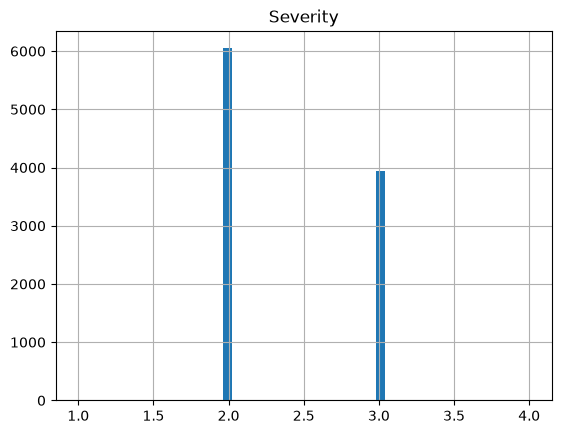

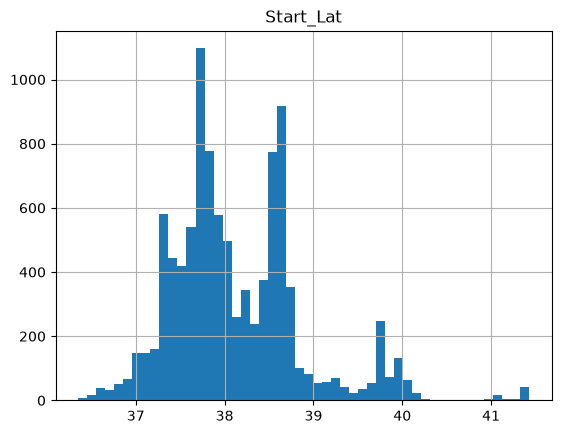

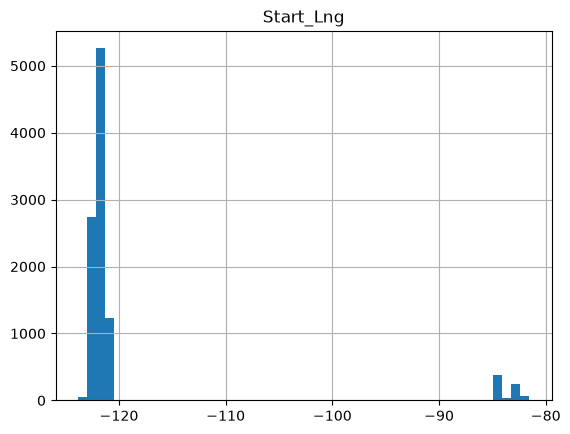

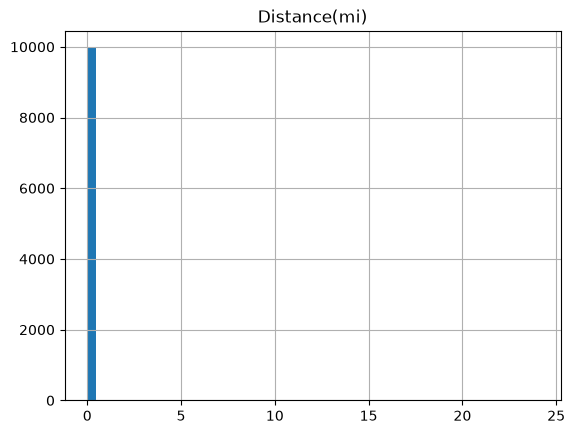

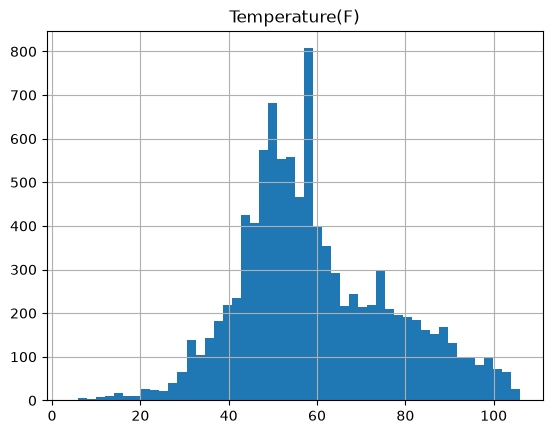

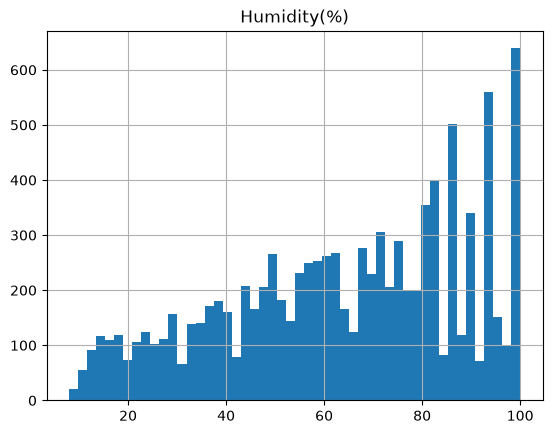

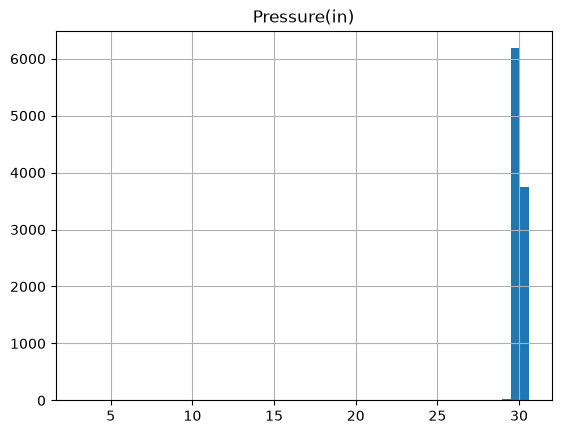

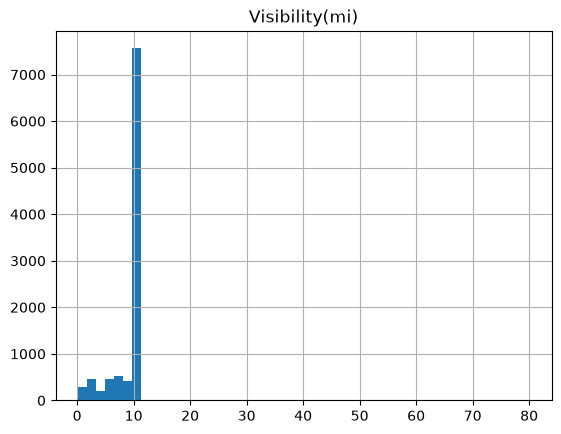

In [167]:
import matplotlib.pyplot as plt

for col in numeric:
    df.hist(
        col,
        bins=50
    )
    plt.savefig(f'C:/Users/Reyhane/Desktop/Aiolearn/jalase31/outputs/histof{col}.png',dpi=300)
    plt.show()

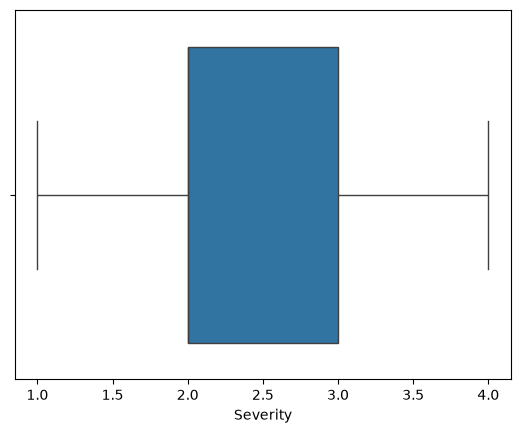

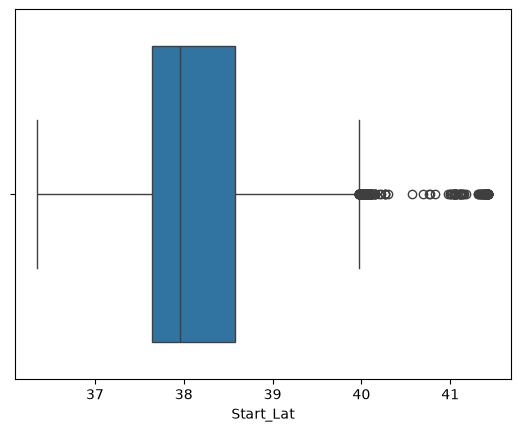

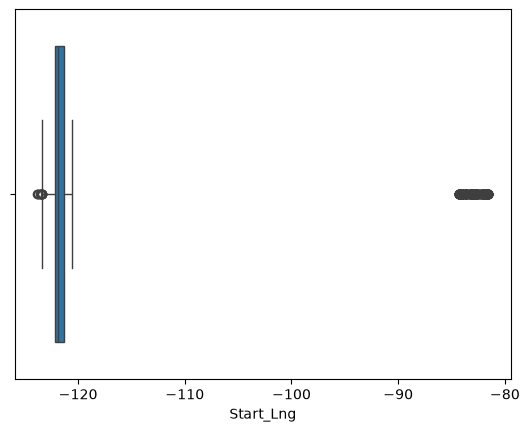

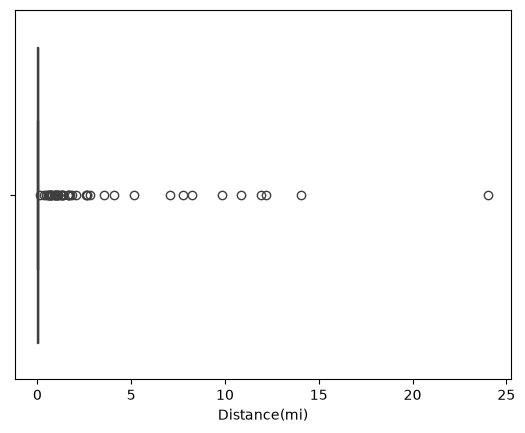

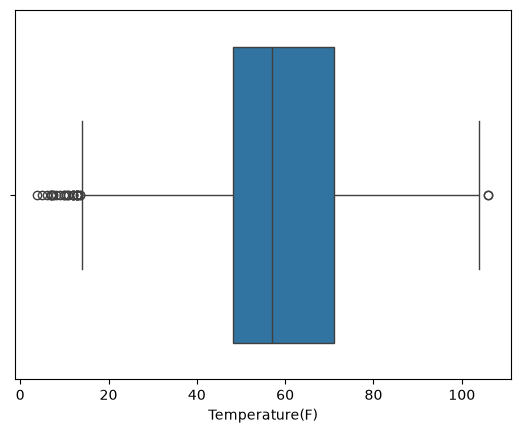

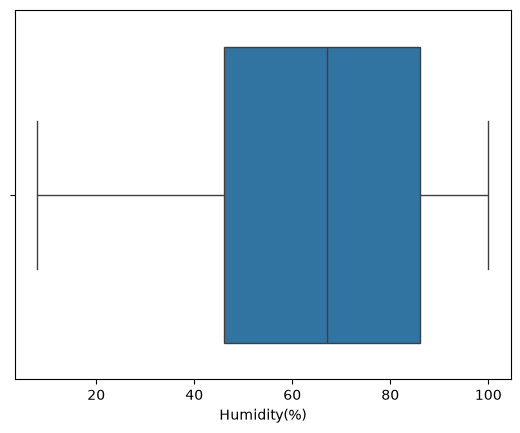

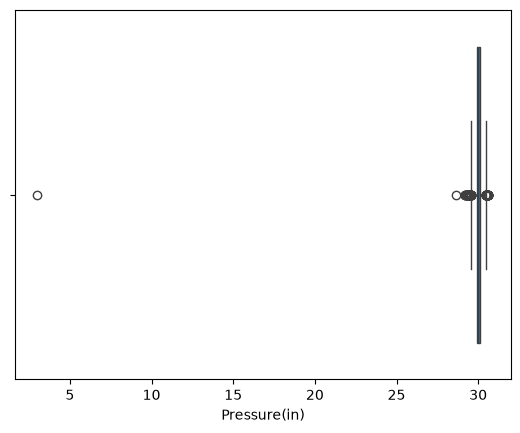

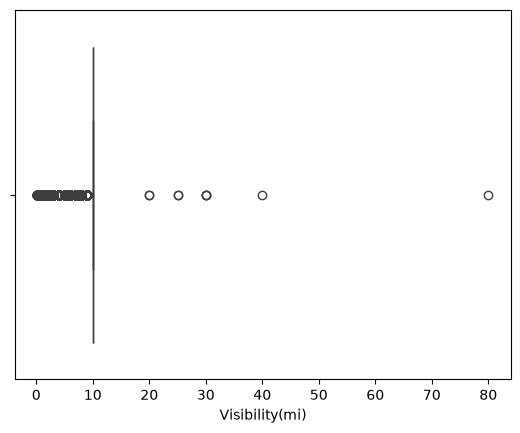

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric:

    sns.boxplot(
        data= df,
        x = col
    )
    plt.show()

In [169]:
for col in numeric:

    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) & (df[col] <= upper)
    ]

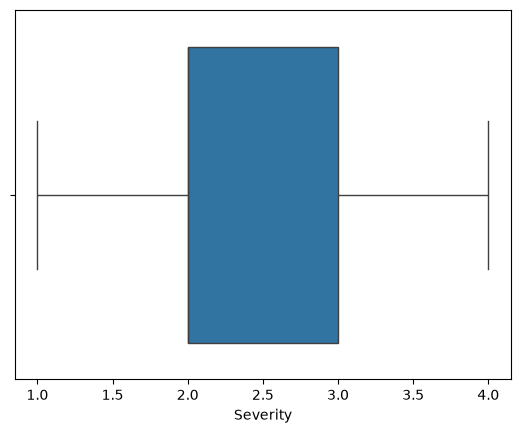

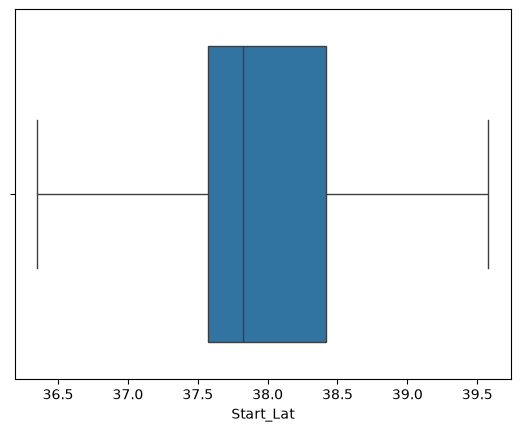

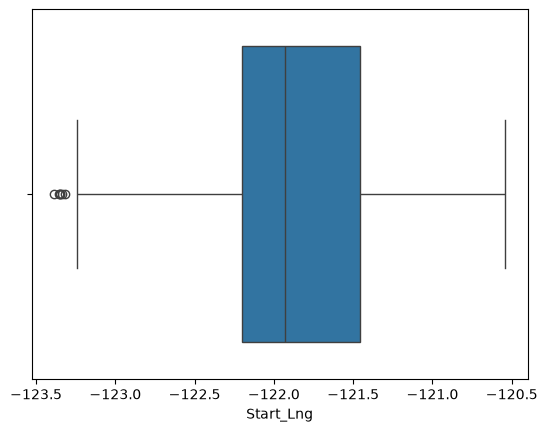

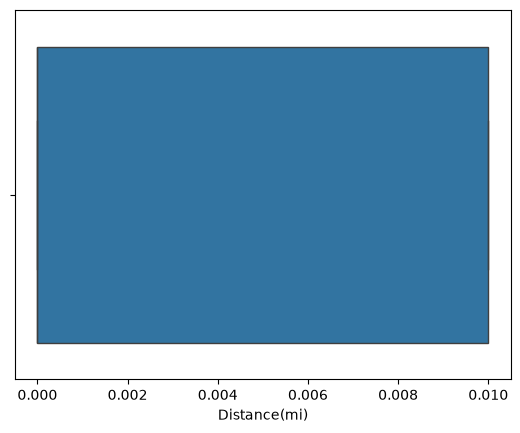

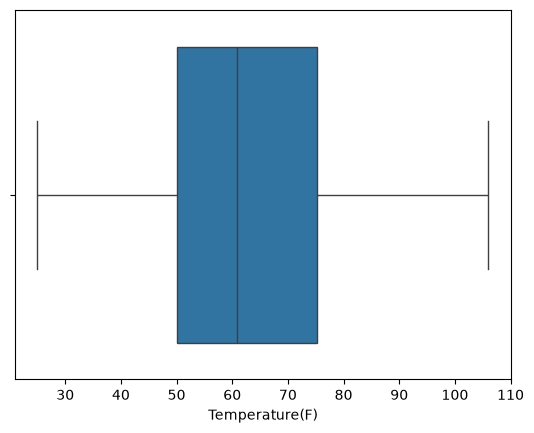

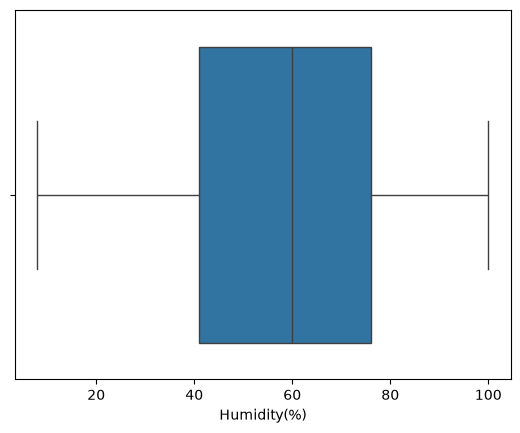

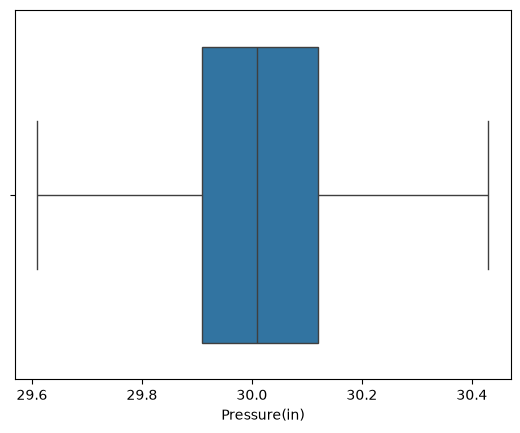

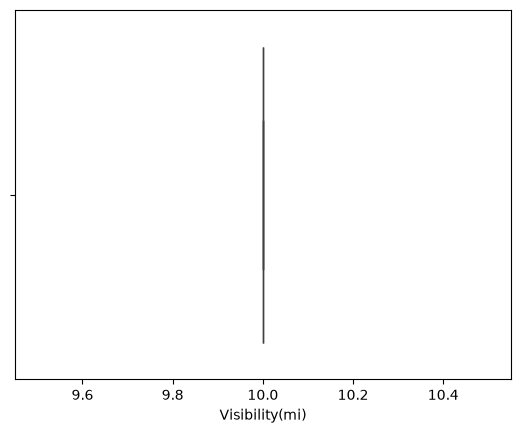

In [170]:

numeric = df.select_dtypes(include=np.number)

for col in numeric:

    sns.boxplot(
        data=df,
        x=col
    )
    plt.show()

In [171]:
pd.get_dummies(df)

,Severity,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Amenity,Bump,...,Weather_Condition_Shallow Fog,Weather_Condition_Smoke,Sunrise_Sunset_Day,Sunrise_Sunset_Night,Civil_Twilight_Day,Civil_Twilight_Night,Nautical_Twilight_Day,Nautical_Twilight_Night,Astronomical_Twilight_Day,Astronomical_Twilight_Night
728,3,38.085300,-122.233017,0.00,75.0,48.0,30.00,10.0,False,False,...,False,False,True,False,True,False,True,False,True,False
729,3,37.631813,-122.084167,0.00,75.0,48.0,30.06,10.0,False,False,...,False,False,True,False,True,False,True,False,True,False
730,2,37.896564,-122.070717,0.00,82.9,31.0,29.97,10.0,False,False,...,False,False,True,False,True,False,True,False,True,False
731,3,37.334255,-122.032471,0.00,75.9,48.0,30.04,10.0,False,False,...,False,False,True,False,True,False,True,False,True,False
732,2,37.250729,-121.910713,0.00,75.2,41.0,30.06,10.0,False,False,...,False,False,True,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,38.701267,-121.077751,0.00,46.4,66.0,30.08,10.0,False,False,...,False,False,True,False,True,False,True,False,True,False
9996,2,36.981407,-122.011192,0.01,52.0,59.0,30.05,10.0,False,False,...,False,False,True,False,True,False,True,False,True,False
9997,3,37.326691,-121.940720,0.01,51.1,50.0,30.04,10.0,False,False,...,False,False,True,False,True,False,True,False,True,False
9998,3,37.930088,-122.324036,0.01,44.1,63.0,30.04,10.0,False,False,...,False,False,True,False,True,False,True,False,True,False


In [172]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

df['Year'] = df.Start_Time.dt.year
df['month'] = df.Start_Time.dt.month
df['Day'] = df.Start_Time.dt.dayofweek
df['Hour'] = df.Start_Time.dt.hour
df['minute'] = df.Start_Time.dt.minute


In [173]:
df = df.drop(columns=['Start_Time'])

<Axes: xlabel='Hour', ylabel='count'>

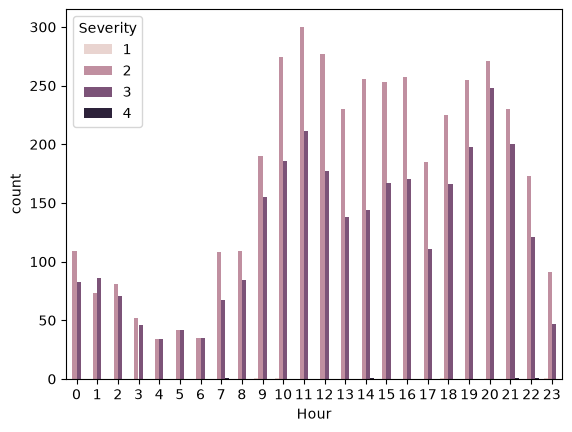

In [174]:
import seaborn as sns

sns.countplot(
    data=df,
    x='Hour',
    hue='Severity'
)

In [190]:
DATA_PATH_clean = "C:/Users/Reyhane/Desktop/Aiolearn/jalase31/data/Clean_US_Accidents_March23.csv"
df.to_csv(DATA_PATH_clean,index=False)

In [188]:
from sklearn.preprocessing import StandardScaler


numeric = df.drop('Severity',axis=1).select_dtypes(include=['int','float']).columns

scaler = StandardScaler()

df[numeric] = scaler.fit_transform(df[numeric])

df.head()

,Severity,Start_Lat,Start_Lng,Distance(mi),Street,City,County,State,Country,Weather_Timestamp,...,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Year,month,Day,Hour,minute
0,3,0.292206,-0.813586,-0.856852,Magazine St,Vallejo,Solano,CA,US,2016-06-21 10:54:00,...,False,Day,Day,Day,Day,-0.255689,-0.781794,-0.959657,-0.615436,0.188322
1,3,-0.558110,-0.496768,-0.856852,I-880 N,Hayward,Alameda,CA,US,2016-06-21 10:54:00,...,False,Day,Day,Day,Day,-0.255689,-0.781794,-0.959657,-0.615436,-0.045722
2,2,-0.061685,-0.468140,-0.856852,I-680 N,Walnut Creek,Contra Costa,CA,US,2016-06-21 10:53:00,...,False,Day,Day,Day,Day,-0.255689,-0.781794,-0.959657,-0.615436,1.065987
3,3,-1.116049,-0.386736,-0.856852,N De Anza Blvd,Cupertino,Santa Clara,CA,US,2016-06-21 10:56:00,...,False,Day,Day,Day,Day,-0.255689,-0.781794,-0.959657,-0.615436,0.597899
4,2,-1.272666,-0.127581,-0.856852,Norman Y Mineta Hwy,San Jose,Santa Clara,CA,US,2016-06-21 09:50:00,...,False,Day,Day,Day,Day,-0.255689,-0.781794,-0.959657,-0.615436,-0.864875


In [189]:
from sklearn.preprocessing import LabelEncoder


categorcal_features = df.select_dtypes(include=['object']).columns

scaler = LabelEncoder()


for col in categorcal_features:
    
    df[col] = scaler.fit_transform(df[col])

C:\Users\Reyhane\AppData\Local\Temp\ipykernel_14168\3215827810.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorcal_features = df.select_dtypes(include=['object']).columns


In [198]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score
import joblib


TARGET = 'Severity'

df = pd.read_csv(DATA_PATH_clean)

X = df.drop(TARGET,axis=1)
y = df['Severity'] - 1


X_train ,X_test , y_train , y_test = train_test_split(
    X,y,test_size=0.2
)

models={
    'LogisticRegression':LogisticRegression(
        max_iter=10000
    ),
    'RandomForestClassifier':RandomForestClassifier(),
    'XGBClassifier':XGBClassifier()
}

for name,model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    print(name)
    print(accuracy_score(y_test,pred))

    joblib.dump(model,f'C:/Users/Reyhane/Desktop/Aiolearn/jalase31/models/{name}.pkl')






C:\Users\Reyhane\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression
0.7009148486981
RandomForestClassifier
0.904292751583392
XGBClassifier
0.9275158339197748


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()

model.fit(X,y)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

<Axes: >

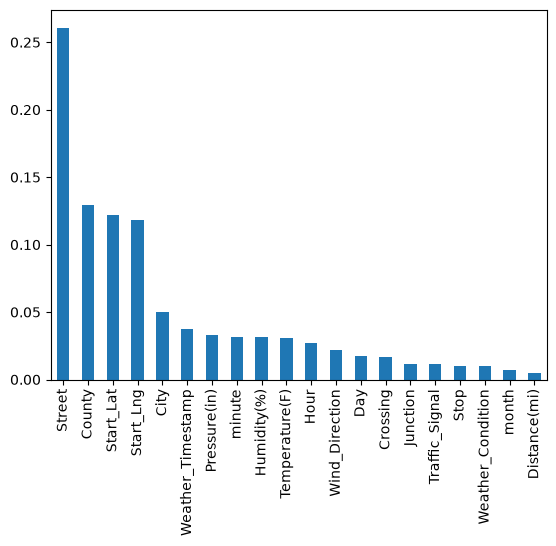

In [201]:
importtences=pd.Series(
    model.feature_importances_,
    index=X.columns
    ).sort_values(ascending=False)

importtences.head(20).plot(kind='bar')

In [204]:
import shap 
import matplotlib.pyplot as plt

explainer=shap.TreeExplainer(model)
shap_value=explainer.shap_values(X_test)
shap.summary_plot(
    shap_value,X_test,show=False
    )
plt.savefig('shap_summery.png',dpi=300)
plt.close()
